# Etape de modilisation:


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
## import des librairie necessaires :

import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
from sklearn.metrics import f1_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from collections import Counter
import seaborn as sns
import tensorflow as tf
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from skopt import BayesSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from google.colab import drive
drive.mount('/content/drive')

##librairie DEEP LEARNING
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Activation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **`Modele Patch_based:`**

###### **`Appliquer les preprocessing`**

In [ ]:
## préprocessing: Création des dossiers X et y avec les données train et test melangé dans X et les labels dans y:
## Fonction qui permet de faire les preprocessing necessaires:

def Dataset_supervise (path, category, color_mode="rgb"):

    """ Dans cette fonction on ajoute l'augmentation de la données des test :
          """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images:
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {os.path.join(path, category)} : {len(img_paths)}")



    ## Lire les images sans les convertir en gris
    for file_path in img_paths:
      img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
      if img is None:
        continue
      if img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

      ##redimentionnement des taille:
      img=cv2.resize(img, (256,256))

      #convertir en RGB (si tu préfères travailler en RGB)
      if color_mode.lower() == "rgb":
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


      img_prp.append(img)



    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X





###### **`création de dossiers d'entrainnement et de test avec 20% de dossier test par rapport au donniers total/ Instancier le modele:`**

In [ ]:
import os, random, shutil


base_dir = "/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid"
test_dir = os.path.join(base_dir, "test")
out_dir  = os.path.join(base_dir, "train", "anomaly_from_test")

random.seed(42)

# récupérer toutes les images anomalies (tous défauts confondus)
candidates = []
for defect in os.listdir(test_dir):
    if defect == "good":
        continue
    defect_dir = os.path.join(test_dir, defect)
    if not os.path.isdir(defect_dir):
        continue
    for p in glob(os.path.join(defect_dir, "*.*")):
        candidates.append((p, defect))

print("Total anomalies candidates:", len(candidates))

n_take = 30
n_take = min(n_take, len(candidates))
chosen = random.sample(candidates, n_take)

# déplacer
for p, defect in chosen:
    dest_defect_dir = os.path.join(out_dir, defect)
    os.makedirs(dest_defect_dir, exist_ok=True)
    shutil.move(p, os.path.join(dest_defect_dir, os.path.basename(p)))

print(f"Déplacé {n_take} images vers {out_dir}")
print("Elles ne sont plus dans test/")


Total anomalies candidates: 57
Déplacé 30 images vers /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test
Elles ne sont plus dans test/


In [ ]:
#GOOD (label 0)
path_good = "/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good"
good_paths = [path_good]

X_train_list, y_train_list = [], []

for category_path in good_paths:
    category = "grid"
    X_good = Dataset_supervise(category_path, category, do_augment=True, k=3)
    y_good = np.zeros(len(X_good), dtype=np.int64)
    X_train_list.append(X_good)
    y_train_list.append(y_good)

#ANOMALIES prélevées du test (label 1)
path_anom_train = "/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test"
anom_defect_dirs = [d for d in glob(os.path.join(path_anom_train, "*")) if os.path.isdir(d)]

for defect_dir in anom_defect_dirs:
    category = "grid"
    X_anom = Dataset_supervise(defect_dir, category, do_augment=True, k=30)
    y_anom = np.ones(len(X_anom), dtype=np.int64)
    X_train_list.append(X_anom)
    y_train_list.append(y_anom)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape, np.unique(y_train, return_counts=True))


Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good/grid : 264
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/thread/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/broken/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/bent/grid : 7
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/metal_contamination/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/ano

In [ ]:
## liste pour stocker X_test et y_test
X_test_grid_aug= []
y_test_grid_aug= []


## chemin du dataset:
path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/grid")

##faire une boucle pour créer le chemin
for cat in categories:
    category = os.path.basename(cat)
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = Dataset_supervise(good_path, category, do_augment=True, k=5)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test_grid_aug.append(X_good)
        y_test_grid_aug.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chaque piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = Dataset_supervise(anomaly_path, category, do_augment=True, k=9)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test_grid_aug.append(X_anom)
            y_test_grid_aug.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test = np.concatenate(X_test_grid_aug, axis=0)
y_test= np.concatenate(y_test_grid_aug, axis=0)

print(X_test.shape, y_test.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape, np.unique(y_test, return_counts=True))

Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/good/grid : 21
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/broken/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/glue/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/bent/grid : 5
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/metal_contamination/grid : 5
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/thread/grid : 5
(396, 256, 256, 3) (396,)
X_test: (396, 256, 256, 3)
y_test: (396,) 

**Ce modèle patch-based non supervisé détecte les anomalies en comparant localement les patches d’une image à une mémoire de patches normaux : plus un patch est éloigné de ce qui est connu comme normal, plus il est suspect, et le score image-level est obtenu en prenant le maximum (ou un percentile élevé) des scores des patches.**

L’objectif est de détecter automatiquement des anomalies sur des images industrielles sans utiliser de labels lors de l’apprentissage.
Le modèle apprend uniquement à reconnaître ce qui est normal. Une image est considérée comme anormale si elle s’éloigne de ce comportement normal

Les images sont fournies au format RGB (256 × 256 × 3).
Elles sont converties en float32 et prétraitées à l’aide de la fonction preprocess_input de MobileNetV2, afin d’être compatibles avec les poids pré-entraînés sur ImageNet.

Aucun prétraitement n’est appliqué aux labels, car le modèle est non supervisé.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# X_train
X_tr_01, X_val_01 = train_test_split(X_train, test_size=0.2, random_state=42)

# Copie pour MobileNetV2 (en [-1,1])
X_tr  = preprocess_input((X_tr_01).astype("float32"))
X_val = preprocess_input((X_val_01).astype("float32"))
X_te  = preprocess_input((X_test).astype("float32"))

print("After preprocess_input:", X_tr.min(), X_tr.max())


After preprocess_input: -0.75686276 0.9843137


*  Charger MobileNetV2 comme extracteur de features (gelé)

On utilise MobileNetV2 pré-entraîné sur ImageNet uniquement pour extraire des caractéristiques (textures, motifs, formes).
On gèle ses poids (trainable=False) car on ne veut pas l’entraîner : le modèle reste non supervisé.

On choisit une couche intermédiaire (block_13_expand_relu) car elle représente un bon compromis entre informations locales et globales.

Sortie : un modèle feat_map_model qui transforme une image en feature maps (cartes de caractéristiques).

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

base = MobileNetV2(input_shape=(256,256,3), include_top=False, weights="imagenet")
base.trainable = False

layer_name = "block_13_expand_relu"   # bon compromis local/global
feat_map_model = Model(base.input, base.get_layer(layer_name).output)

print("Feature map shape:", feat_map_model.output_shape)


/tmp/ipython-input-308448550.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=(256,256,3), include_top=False, weights="imagenet")


Feature map shape: (None, 16, 16, 576)


*  Générer les feature maps pour train/val/test

On passe toutes les images dans feat_map_model.predict() pour obtenir leurs représentations profondes :

FM_tr : feature maps des images d’entraînement

FM_val : feature maps des images de validation

FM_te : feature maps des images de test

Chaque image devient un tenseur (H, W, C) (ex : 16×16×576), où :

H×W = positions spatiales (zones de l’image)

C = nombre de caractéristiques extraites (motifs détectés)

In [ ]:
FM_tr  = feat_map_model.predict(X_tr,  batch_size=32, verbose=1)
FM_val = feat_map_model.predict(X_val, batch_size=32, verbose=0)
FM_te  = feat_map_model.predict(X_te,  batch_size=32, verbose=1)

print(FM_tr.shape, FM_val.shape, FM_te.shape)


40/40 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 438ms/step
(1267, 16, 16, 576) (317, 16, 16, 576) (48, 16, 16, 576)


* Transformer les feature maps en patches

Une feature map contient une grille (H×W) de “points”.
Chaque point correspond à une zone locale de l’image originale (on parle de “patch profond”).

Avec reshape(-1, C), on convertit :

(N, H, W, C) → (N*H*W, C)

Ainsi :

P_tr = liste de tous les patches du train

P_val = liste de tous les patches de la validation

P_te = liste de tous les patches du test

Idée : au lieu de comparer des images entières, on compare des petites zones (plus efficace pour détecter des défauts locaux).

In [ ]:
H, W, C = FM_tr.shape[1], FM_tr.shape[2], FM_tr.shape[3]

P_tr  = FM_tr.reshape(-1, C)
P_val = FM_val.reshape(-1, C)
P_te  = FM_te.reshape(-1, C)

print("Patches:", P_tr.shape, P_val.shape, P_te.shape)


Patches: (324352, 576) (81152, 576) (12288, 576)


* Normaliser les patches (L2)

On normalise chaque patch (vecteur de taille C) avec la norme L2 pour que tous les vecteurs soient comparés dans le même espace.

But :

éviter que la comparaison dépende juste de l’intensité

comparer plutôt la “direction” des features (structure / texture)

Le eps sert à éviter une division par zéro si un vecteur est très proche de 0.

In [ ]:
## on normalise  car on vaux comparer les vecteurs dans le même espaces
eps = 1e-8
P_tr  = P_tr  / (np.linalg.norm(P_tr,  axis=1, keepdims=True) + eps)
P_val = P_val / (np.linalg.norm(P_val, axis=1, keepdims=True) + eps)
P_te  = P_te  / (np.linalg.norm(P_te,  axis=1, keepdims=True) + eps)


* Construire une mémoire de patches normaux (P_mem)

Le nombre total de patches peut devenir énorme (N*H*W).
Pour limiter la RAM et accélérer le calcul, on garde au maximum max_mem patches issus du train :

si trop de patches → on tire un sous-ensemble aléatoire

sinon → on garde tout

P_mem représente la mémoire de la normalité : une base de référence de patches “normaux”.

In [ ]:
max_mem = 100000
if P_tr.shape[0] > max_mem:
    idx = np.random.choice(P_tr.shape[0], size=max_mem, replace=False)
    P_mem = P_tr[idx]
else:
    P_mem = P_tr

print("Memory patches:", P_mem.shape)


Memory patches: (100000, 576)


* Apprendre la normalité via k-NN (Nearest Neighbor)

On entraîne un modèle k-NN sur cette mémoire :

knn.fit(P_mem)

Ensuite, pour chaque patch de validation et de test, on cherche son plus proche patch normal dans P_mem :

d_val : distances des patches val vers la mémoire

d_te : distances des patches test vers la mémoire

Interprétation :

distance faible → patch ressemble à un patch normal → normal

distance élevée → patch “jamais vu” → possiblement anomalie

In [ ]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=1, algorithm="auto")
knn.fit(P_mem)

d_val, _ = knn.kneighbors(P_val, return_distance=True)
d_te,  _ = knn.kneighbors(P_te,  return_distance=True)


* Regrouper les distances par image (patch → image)

À ce stade, les distances sont calculées patch par patch.
On les regroupe par image avec un reshape :

(N*H*W, 1) → (N, H*W)

Ainsi :

D_val[i] = toutes les distances patch de l’image i en validation

D_te[i] = toutes les distances patch de l’image i en test

In [ ]:
N_val = FM_val.shape[0]
N_te  = FM_te.shape[0]

D_val = d_val.reshape(N_val, H*W)
D_te  = d_te.reshape(N_te,  H*W)

# Score image-level :
val_scores  = D_val.max(axis=1)                 # très sensible aux défauts locaux
test_scores = D_te.max(axis=1)

# Alternative plus stable :
# val_scores  = np.percentile(D_val, 99, axis=1)
# test_scores = np.percentile(D_te, 99, axis=1)


* Évaluer le modèle (uniquement pour mesurer la performance)

Même si le modèle est non supervisé, on utilise y_test uniquement pour évaluer :

matrice de confusion

rapport de classification (déséquilibré)

ROC-AUC (sur les scores, pas sur y_pred)

PR-AUC (souvent plus pertinent si anomalies > rares)

Important :

la ROC-AUC et PR-AUC utilisent test_scores (score continu), donc elles évaluent la qualité du ranking, indépendamment du seuil.

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score
from imblearn.metrics import classification_report_imbalanced

threshold = np.percentile(val_scores, 64.5)
y_pred = (test_scores >= threshold).astype(int)

print("Threshold:", threshold)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\n", classification_report_imbalanced(y_test, y_pred, digits=3))

print("ROC-AUC:", roc_auc_score(y_test, test_scores))
print("PR-AUC :", average_precision_score(y_test, test_scores))


Threshold: 0.4592680513858795
Confusion matrix:
 [[15  6]
 [ 8 19]]

                    pre       rec       spe        f1       geo       iba       sup

          0      0.652     0.714     0.704     0.682     0.709     0.503        21
          1      0.760     0.704     0.714     0.731     0.709     0.502        27

avg / total      0.713     0.708     0.710     0.709     0.709     0.503        48

ROC-AUC: 0.8165784832451499
PR-AUC : 0.8721940314378223


Le modèle patch-based non supervisé arrive à distinguer correctement les images normales des images anormales. Avec un ROC-AUC d’environ 0,82, il montre une bonne capacité globale à séparer les deux types d’images. Le PR-AUC élevé (0,87) indique que les anomalies sont généralement bien classées parmi les scores les plus élevés, ce qui est important en détection d’anomalies.

La matrice de confusion montre que le modèle détecte environ 70 % des anomalies, tout en produisant un nombre modéré de fausses alertes. Ce comportement est normal pour un modèle non supervisé, car il n’a appris que la notion de “normalité” et non une frontière de classification précise.

Globalement, ces résultats sont satisfaisants pour une approche non supervisée : le modèle identifie correctement la majorité des défauts sans utiliser de données annotées à l’entraînement, avec un compromis raisonnable entre anomalies manquées et fausses alertes.

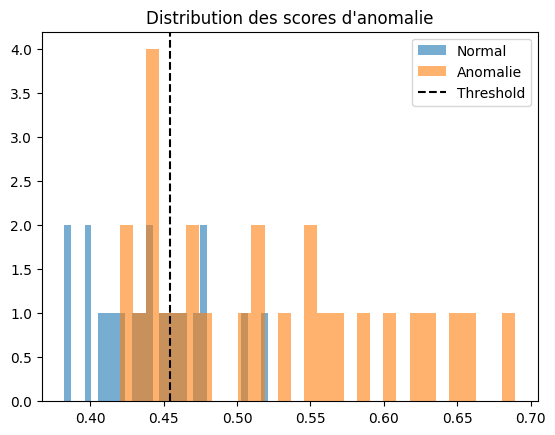

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(test_scores[y_test==0], bins=30, alpha=0.6, label="Normal")
plt.hist(test_scores[y_test==1], bins=30, alpha=0.6, label="Anomalie")
plt.axvline(threshold, color="k", linestyle="--", label="Threshold")
plt.legend()
plt.title("Distribution des scores d'anomalie")
plt.show()


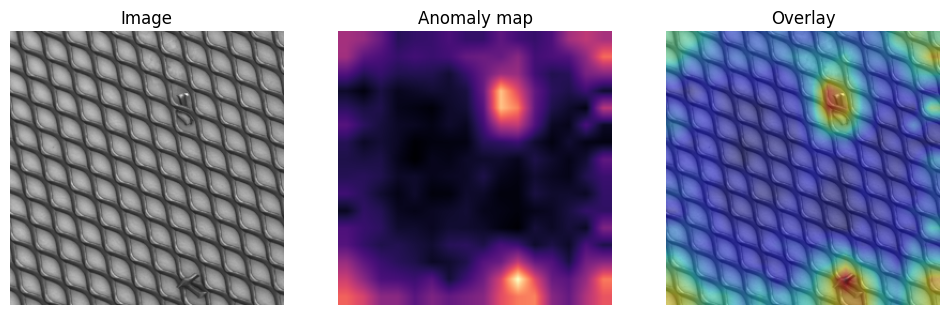

In [ ]:
i = 40

#  anomaly map (H,W) + resize (256,256)
amap = D_te[i].reshape(H, W).astype("float32")
amap_up = tf.image.resize(amap[None, ..., None], (256,256)).numpy()[0, ..., 0]

#  si X_test est preprocess_input, remettre en [0,255] pour afficher
img = X_test[i]
if img.min() < 0:  # typique preprocess_input MobileNetV2
    img_show = ((img + 1.0) * 127.5).clip(0,255).astype("uint8")
else:
    img_show = img.astype("uint8") if img.max() > 1.5 else (img*255).astype("uint8")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img_show); plt.title("Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(amap_up, cmap="magma"); plt.title("Anomaly map"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(img_show); plt.imshow(amap_up, cmap="jet", alpha=0.4); plt.title("Overlay"); plt.axis("off")
plt.show()


###### **`Utilisation du modele PAtch pour classification binaire:`**

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

# Split d'abord (avec stratify)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Convert float32
X_tr  = X_tr.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# Si images en [0,1], remonter en [0,255] (preprocess_input MobileNetV2 assume [0,255])
if X_tr.max() <= 1.5:
    X_tr  *= 255.0
    X_val *= 255.0
    X_test*= 255.0

# reprocess MobileNetV2
X_tr  = preprocess_input(X_tr)
X_val = preprocess_input(X_val)
X_test= preprocess_input(X_test)

print("After preprocess_input:", X_tr.min(), X_tr.max())
print("y_tr unique:", np.unique(y_tr), " | y_val unique:", np.unique(y_val))


After preprocess_input: -0.84313726 1.0
y_tr unique: [0 1]  | y_val unique: [0 1]


In [ ]:
from tensorflow.keras.applications import MobileNetV2


base = MobileNetV2(input_shape=(256,256,3), include_top=False, weights="imagenet")
base.trainable = False

layer_name = "block_13_expand_relu"   # bon compromis local/global
feat_map_model = Model(base.input, base.get_layer(layer_name).output)

print("Feature map shape:", feat_map_model.output_shape)  # ex (None, 16,16,576)

/tmp/ipython-input-1860830251.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=(256,256,3), include_top=False, weights="imagenet")


Feature map shape: (None, 16, 16, 576)


In [ ]:
## utiliser le modele PAtch_Based pour de la classification binaire:

x = feat_map_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
out = Dense(1, activation="sigmoid")(x)

clf_model = Model(feat_map_model.input, out)

clf_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 690,241 (2.63 MB)

 Trainable params: 73,985 (289.00 KB)

 Non-trainable params: 616,256 (2.35 MB)

In [ ]:
## Ajout de callbak pour stopper le modele si la val_loss stagne
early_stopping= EarlyStopping(patience=5, min_delta=0.001,verbose=1, mode='min',monitor= "val_loss")

reduceLR= ReduceLROnPlateau( monitor= "val_loss",patience=3, min_delta=0.01, factor=0.1, mode='min',verbose=1,cooldown=4)


In [ ]:
clf_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy", "AUC"])

In [ ]:
history = clf_model.fit(X_tr, y_tr, validation_data=(X_val, y_val),epochs=10,batch_size=32,callbacks=[reduceLR, early_stopping],verbose=1)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - AUC: 0.5565 - accuracy: 0.5560 - loss: 0.7171 - val_AUC: 0.7233 - val_accuracy: 0.6809 - val_loss: 0.6389 - learning_rate: 0.0010
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - AUC: 0.7062 - accuracy: 0.6460 - loss: 0.6269 - val_AUC: 0.7529 - val_accuracy: 0.6658 - val_loss: 0.6157 - learning_rate: 0.0010
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - AUC: 0.7388 - accuracy: 0.6815 - loss: 0.6052 - val_AUC: 0.7918 - val_accuracy: 0.7286 - val_loss: 0.5752 - learning_rate: 0.0010
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - AUC: 0.7794 - accuracy: 0.7204 - loss: 0.5739 - val_AUC: 0.8288 - val_accuracy: 0.7211 - val_loss: 0.5559 - learning_rate: 0.0010
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - AUC: 0.8192 - accuracy: 0.7437 - loss: 0.5367 - val_AUC: 0.8630 - val_accuracy: 0.7965 - val_loss: 0.5078 - learning_rate: 0.0010
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - AUC: 0.8625 - accuracy: 0.7893 - loss:

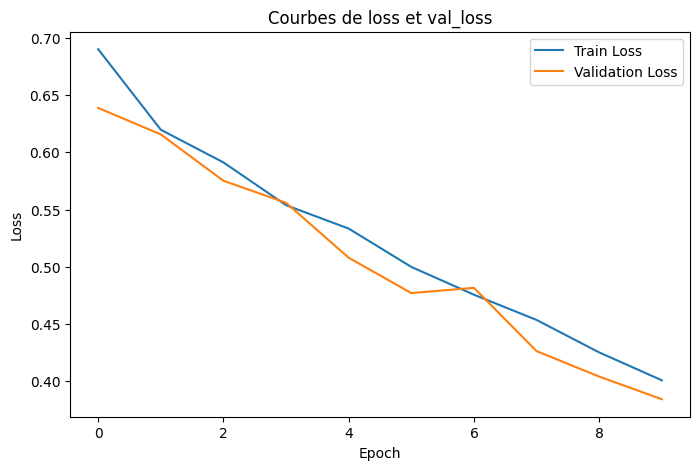

In [ ]:
## afficher la coube de l'evolution de la fonction de la perte loss et celle de Val_loss:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')


plt.title('Courbes de loss et val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
##faire les prediction avec X_test:
y_proba = clf_model.predict(X_test).ravel()      # valeurs continues [0,1]
y_pred  = (y_proba >= 0.8).astype(int)       # classes 0/1

13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred): .2f}")
print(f"F1-score: {f1_score(y_test, y_pred):.2f}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")

Accuracy : 0.32
Precision: 0.00
Recall:  0.00
F1-score: 0.00
Confusion Matrix:
 [[126   0]
 [270   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###### **`Choix de différentes seuils:`**

In [ ]:
## Reconstruire et créer la carte d’erreur (anomaly_map)

# Reconstruction validation (good)
X_val_rec = ae.predict(X_val, batch_size=32, verbose=1)
val_map = np.mean(np.abs(X_val - X_val_rec), axis=-1)

# Reconstruction test
X_test_rec = ae.predict(X_test, batch_size=32, verbose=1)
test_map = np.mean(np.abs(X_test - X_test_rec), axis=-1)


In [ ]:
## Choisir 2 seuils sur les données normales (X_val):
##Seuil local pixel-wise (pour capter les petites anomalies)

pixel_thr = np.percentile(val_map, 99)  # strict, à tester: 98, 99, 99.5

## Seuil “intensité max” (petites anomalies très fortes)
max_thr = np.percentile(val_map.reshape(len(val_map), -1).max(axis=1), 99)

## Seuil surface (taille de région) (pour capter les anomalies étendues)
val_mask = val_map >= pixel_thr
val_area = val_mask.sum(axis=(1,2))  # nb pixels anormaux par image

area_thr = np.percentile(val_area, 99)  # seuil surface basé sur le normal

In [ ]:
## Décision finale (règle min/max):

# masque pixel-wise
test_mask = test_map >= pixel_thr
test_area = test_mask.sum(axis=(1,2))

# intensité locale
test_max = test_map.reshape(len(test_map), -1).max(axis=1)

# Règle de décision à 2 critères
y_pred = ((test_max >= max_thr) | (test_area >= area_thr)).astype(int)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

print("pixel_thr:", pixel_thr, "max_thr:", max_thr, "area_thr:", area_thr)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

print("Recall anomalie:", recall_score(y_test, y_pred, pos_label=1))
print("Precision anomalie:", precision_score(y_test, y_pred, pos_label=1))
print("F1 anomalie:", f1_score(y_test, y_pred, pos_label=1))


Le backbone convolutionnel pré-entraîné initialement utilisé pour la classification supervisée est réutilisé dans un cadre non supervisé en tant qu’extracteur de caractéristiques. Les couches de classification sont supprimées, et le modèle est exploité pour produire des représentations visuelles permettant la détection et la localisation d’anomalies sans recours à des labels lors de l’entraînement.